## Research question: Can we analyze Netflix content to identify patterns in genres and build a simple recommendation system based on content similarity?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
columns = ['type', 'title', 'country', 'release_year', 
        'rating', 'duration', 'listed_in', 'description']
df = df[columns]

In [4]:
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

In [5]:
df.isnull().sum()

type            0
title           0
country         0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

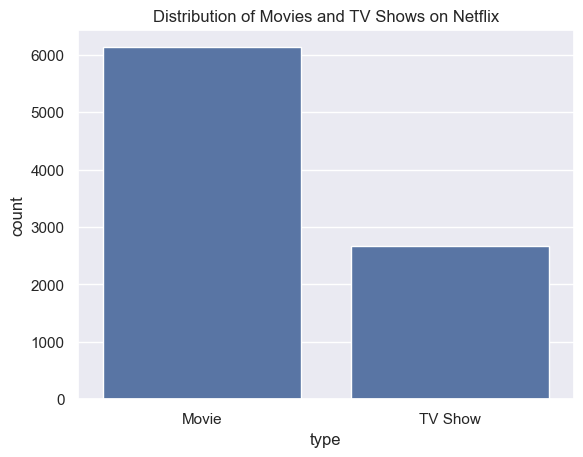

In [6]:
sns.set(style="darkgrid")
sns.countplot(x='type', data=df)
plt.title('Distribution of Movies and TV Shows on Netflix')
plt.show()

The dataset contains significantly more movies than TV shows, indicating that Netflix’s catalog is dominated by movie content.

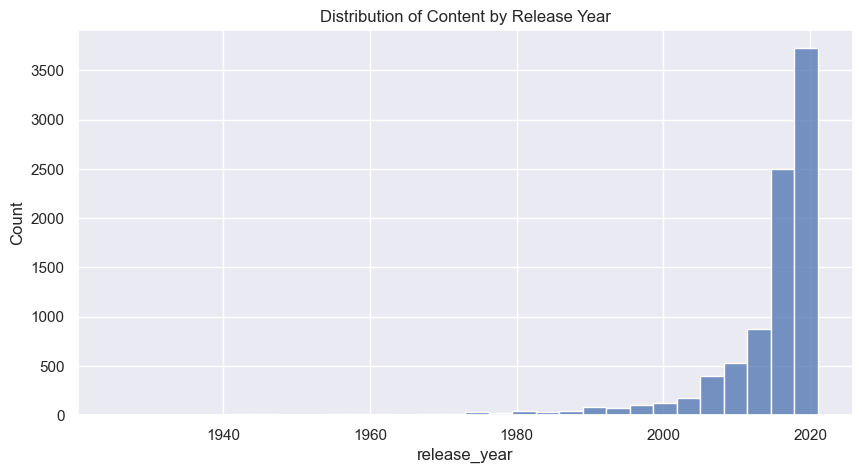

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30)
plt.title('Distribution of Content by Release Year')
plt.show()

Most content was produced after 2000, with a peak in recent years, reflecting Netflix’s focus on modern content.

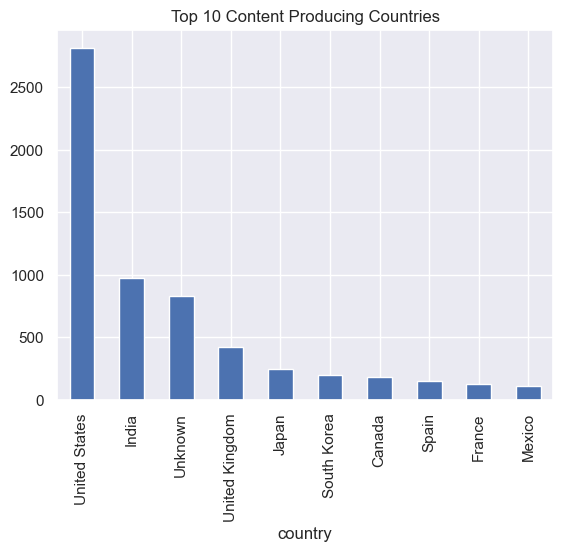

In [8]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Content Producing Countries')
plt.show()

The majority of content originates from the United States.

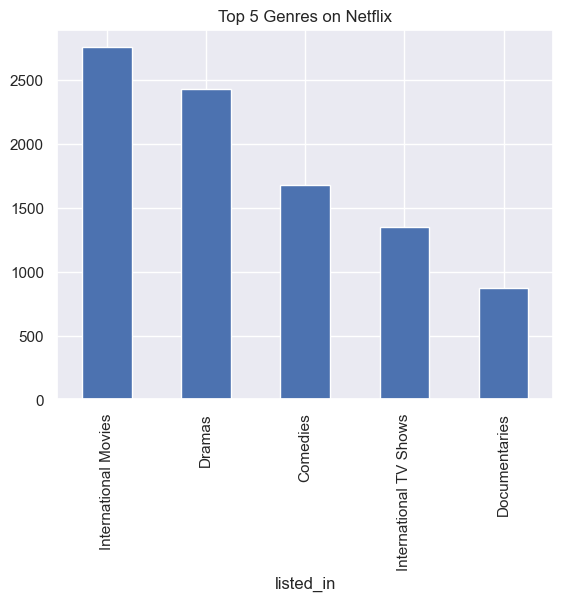

In [9]:
genres = df['listed_in'].str.split(', ').explode()

genres.value_counts().head(5).plot(kind='bar')
plt.title('Top 5 Genres on Netflix')
plt.show()

The most common genres include International Movies, Dramas, and Comedies, with International content being the most dominant category.

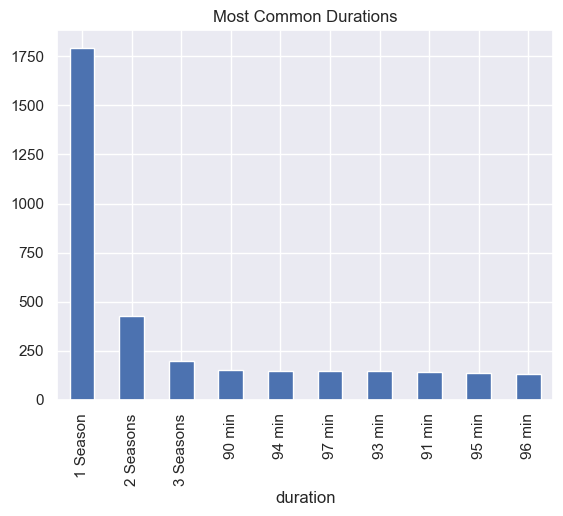

In [10]:
df['duration'].value_counts().head(10).plot(kind='bar')
plt.title('Most Common Durations')
plt.show()

In [11]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract('([a-zA-Z]+)')

In [12]:
df[['duration', 'duration_num', 'duration_type']]

,duration,duration_num,duration_type
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons
...,...,...,...
8802,158 min,158.0,min
8803,2 Seasons,2.0,Seasons
8804,88 min,88.0,min
8805,88 min,88.0,min


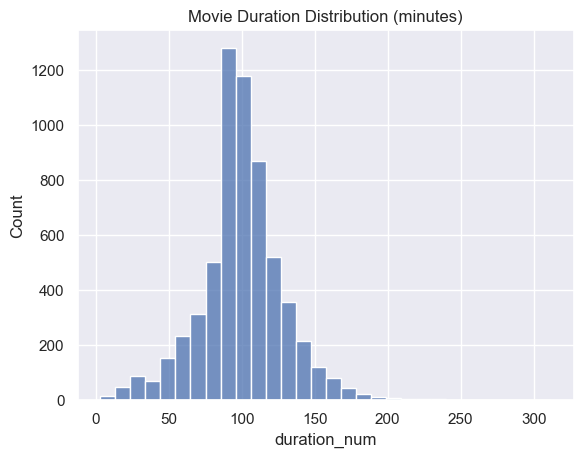

In [13]:
movies = df[df['duration_type'] == 'min']

sns.histplot(movies['duration_num'], bins=30)
plt.title('Movie Duration Distribution (minutes)')
plt.show()

Most movies last between 90 and 100 minutes.

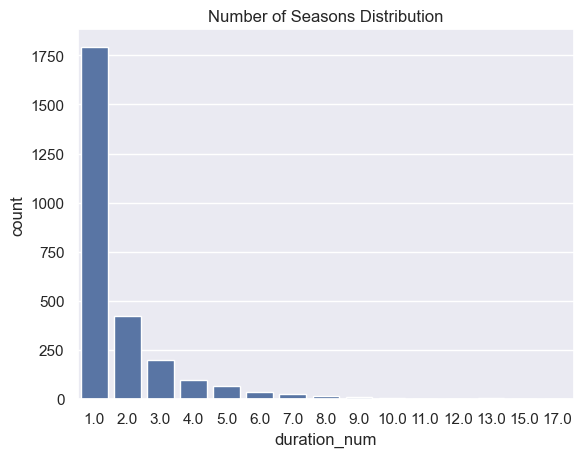

In [14]:
shows = df[df['duration_type'].isin(['Season', 'Seasons'])]

sns.countplot(x='duration_num', data=shows)
plt.title('Number of Seasons Distribution')
plt.show()

Most TV shows on Netflix have only one season, with significantly fewer shows having multiple seasons.

### Unsupervised learning

In [15]:
# df['content'] = df['description'] - low-quality recommendations
# df['content'] = df['listed_in'] + df['description'] - add "listed_in" - the results improved

df['content'] = (
    df['listed_in'] + ' ' + df['listed_in'] + ' ' +
    df['description'] + ' ' +
    df['rating'].astype(str) #Genre information was added twice to give it more importance. The rating was also included to improve the model.
)

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    min_df=3,      # remove very rare words
    max_df=0.7,    # remove very frequent words
    ngram_range=(1,2)  # include single words and word pairs
)

tfidf_matrix = tfidf.fit_transform(df['content'])

# similarity
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim):
    idx = indices[title]
    
    content_type = df.loc[idx, 'type']
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    filtered_scores = []
    for i, score in sim_scores:
        if df.loc[i, 'type'] == content_type:
            filtered_scores.append((i, score))
    
    filtered_scores = filtered_scores[1:6]
    
    movie_indices = [i[0] for i in filtered_scores]
    scores = [i[1] for i in filtered_scores]
    
    result = df[['title']].iloc[movie_indices].copy()
    result['similarity_score'] = scores
    
    return result

get_recommendations("Stranger Things")

,title,similarity_score
3187,Nightflyers,0.648080
6953,Helix,0.595507
1473,Chilling Adventures of Sabrina,0.568784
241,Manifest,0.535176
5287,The Vampire Diaries,0.498492


After improving the model by adding genre information, the recommendations became better. For example, for "Stranger Things", the system suggests similar shows like "Nightflyers" and "Helix", which have similar themes like science fiction and mystery.

### Supervised learning

In [16]:
X = tfidf_matrix
y = df['type']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1214
     TV Show       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



In [22]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


Supervised learning was used to build a classification model. The goal was to predict whether content is a movie or a TV show.